In [ ]:
!nvidia-smi

!pip uninstall -y numpy ultralytics roboflow -q

# Install pinned, compatible versions together (avoids resolver conflicts)
!pip install numpy==1.26.4 ultralytics==8.3.59 roboflow opencv-python-headless -q

# Restart the kernel to load the new versions cleanly
import os
os.kill(os.getpid(), 9)

Sat Sep  5 07:29:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Run this AFTER the kernel restarts (run it manually, second)

import os
HOME = os.getcwd()

from IPython import display
display.clear_output()

!yolo settings sync=False
import ultralytics
ultralytics.checks()

from ultralytics import YOLO
from IPython.display import display, Image
from roboflow import Roboflow
import torch
import torch.nn as nn

from google.colab import drive
drive.mount('/content/drive')

print("✅ Environment ready. HOME =", HOME)

Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.7/112.6 GB disk)
Mounted at /content/drive
✅ Environment ready. HOME = /content


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_ACTUAL_KEY")
project = rf.workspace("nurs-workspace-uplim").project("wound-cw2to")
version = project.version(6)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to wound-6 in yolov8:: 100%|██████████| 3005/3005 [00:00<00:00, 4572.61it/s]


In [ ]:
# Print per-class counts for train/valid/test — ORIGINAL dataset

import os
from collections import Counter

root = dataset.location  # e.g. /content/wound-5

with open(os.path.join(root, "data.yaml")) as f:
    import yaml
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']
print("Classes:", class_names, "\n")

def get_class_id(label_path):
    with open(label_path) as f:
        line = f.readline().strip()
        return int(line.split()[0]) if line else None  # None = empty label file

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(root, split, "images")
    lbl_dir = os.path.join(root, split, "labels")

    if not os.path.exists(img_dir):
        print(f"{split}: folder not found\n")
        continue

    total_images = len(os.listdir(img_dir))
    class_counts = Counter()
    empty_count = 0
    missing_label_count = 0

    for img_name in os.listdir(img_dir):
        base = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")

        if not os.path.exists(lbl_path):
            missing_label_count += 1
            continue

        if os.path.getsize(lbl_path) == 0:
            empty_count += 1
            continue

        cid = get_class_id(lbl_path)
        if cid is not None:
            class_counts[cid] += 1

    print(f"=== {split.upper()} ===")
    print(f"Total images: {total_images}")
    for cid in sorted(class_names.keys()) if isinstance(class_names, dict) else range(len(class_names)):
        cname = class_names[cid]
        print(f"  {cname}: {class_counts[cid]}")
    print(f"  Empty label files (no objects): {empty_count}")
    print(f"  Missing label files entirely: {missing_label_count}")
    print()

Classes: ['mild', 'normal', 'severe'] 

=== TRAIN ===
Total images: 1140
  mild: 480
  normal: 180
  severe: 480
  Empty label files (no objects): 0
  Missing label files entirely: 0

=== VALID ===
Total images: 180
  mild: 60
  normal: 60
  severe: 60
  Empty label files (no objects): 0
  Missing label files entirely: 0

=== TEST ===
Total images: 180
  mild: 60
  normal: 60
  severe: 60
  Empty label files (no objects): 0
  Missing label files entirely: 0



In [ ]:
# Simple augmentation: brightness/contrast/noise only

import os, cv2, random, yaml, shutil

!pip install -q albumentations opencv-python-headless
import albumentations as A

root = dataset.location

with open(os.path.join(root, "data.yaml")) as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']
normal_id = [i for i, n in enumerate(class_names) if n.lower() == "normal"][0]
print("Normal class id:", normal_id)

random.seed(42)

# pixel-only transforms — never touch bounding boxes, so labels stay valid
transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.9),
    A.GaussNoise(p=0.3),
])

def augment_image_only(img_path, out_img_path):
    image = cv2.imread(img_path)
    result = transform(image=image)
    cv2.imwrite(out_img_path, result['image'])

print("Setup done.")

Normal class id: 1
Setup done.


In [ ]:
# Collect existing train/normal images+labels (same as before)

train_img_dir = os.path.join(root, "train", "images")
train_lbl_dir = os.path.join(root, "train", "labels")

def get_class_id(label_path):
    with open(label_path) as f:
        line = f.readline().strip()
        return int(line.split()[0]) if line else None

normal_train_files = []
for img_name in os.listdir(train_img_dir):
    base = os.path.splitext(img_name)[0]
    lbl_path = os.path.join(train_lbl_dir, base + ".txt")
    if os.path.exists(lbl_path) and get_class_id(lbl_path) == normal_id:
        normal_train_files.append((os.path.join(train_img_dir, img_name), lbl_path))

print(f"Normal images in train: {len(normal_train_files)}")

Normal images in train: 180


In [ ]:
# Augment Normal train images: 180 → 480 (add 300)
# Simple pixel-only augmentation — label file is just copied, unchanged

needed = 480 - len(normal_train_files)
print(f"Need to generate: {needed} new augmented Normal images")

for i in range(needed):
    img_path, lbl_path = normal_train_files[i % len(normal_train_files)]
    base = os.path.splitext(os.path.basename(img_path))[0]
    out_img = os.path.join(train_img_dir, f"{base}_aug{i}.jpg")
    out_lbl = os.path.join(train_lbl_dir, f"{base}_aug{i}.txt")

    augment_image_only(img_path, out_img)
    shutil.copy(lbl_path, out_lbl)  # labels unchanged since pixels-only aug doesn't move boxes

print(f"Done. Added {needed} augmented Normal images directly into train/")

Need to generate: 300 new augmented Normal images
Done. Added 300 augmented Normal images directly into train/


In [ ]:
# Summary table: per-class counts across train/valid/test

import pandas as pd
from collections import Counter

def get_class_id(label_path):
    with open(label_path) as f:
        line = f.readline().strip()
        return int(line.split()[0]) if line else None

summary = {cname: {} for cname in class_names}
totals = {}

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(root, split, "images")
    lbl_dir = os.path.join(root, split, "labels")

    counts = Counter()
    for img_name in os.listdir(img_dir):
        base = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")
        if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
            cid = get_class_id(lbl_path)
            if cid is not None:
                counts[cid] += 1

    for cid, cname in enumerate(class_names):
        summary[cname][split.capitalize()] = counts[cid]

    totals[split.capitalize()] = len(os.listdir(img_dir))

df = pd.DataFrame(summary).T
df = df[["Train", "Valid", "Test"]]  # order columns
df["Total"] = df.sum(axis=1)

# add a Total row
total_row = pd.DataFrame({
    "Train": [df["Train"].sum()],
    "Valid": [df["Valid"].sum()],
    "Test": [df["Test"].sum()],
    "Total": [df["Total"].sum()]
}, index=["Total"])

df_final = pd.concat([df, total_row])
print(df_final.to_string())

        Train  Valid  Test  Total
mild      480     60    60    600
normal    480     60    60    600
severe    480     60    60    600
Total    1440    180   180   1800


In [ ]:
# Re-establish dataset paths (no need to re-download or re-augment — files already on disk)

import os

# adjust this to your actual dataset folder — check the error log, it showed /content/wound-6
root = "/content/wound-6"
yaml_path = os.path.join(root, "data.yaml")

import yaml
with open(yaml_path) as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']
print(data_yaml)

{'names': ['mild', 'normal', 'severe'], 'nc': 3, 'roboflow': {'license': 'CC BY 4.0', 'project': 'wound-cw2to', 'url': 'https://universe.roboflow.com/nurs-workspace-uplim/wound-cw2to/dataset/6', 'version': 6, 'workspace': 'nurs-workspace-uplim'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


In [ ]:
yaml_content = """
nc: 3
scales:
  n: [1.00, 1.00, 1024]

backbone:
  - [-1, 1, TorchVision, [1280, 'efficientnet_v2_s', 'DEFAULT', True, 2, True]]  # 0
  - [0, 1, Index, [48, 3]]     # 1  P2 raw feature, 160x160
  - [0, 1, Index, [64, 4]]     # 2  P3 raw feature, 80x80
  - [0, 1, Index, [160, 6]]    # 3  P4 raw feature, 40x40
  - [0, 1, Index, [1280, 8]]   # 4  P5 raw feature, 20x20

head:
  - [-1, 1, SPPF, [1280, 5]]                    # 5

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 6
  - [[-1, 3], 1, Concat, [1]]                   # 7
  - [-1, 2, C3k2, [256, False]]                 # 8

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 9
  - [[-1, 2], 1, Concat, [1]]                   # 10
  - [-1, 2, C3k2, [128, False]]                 # 11

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 12
  - [[-1, 1], 1, Concat, [1]]                   # 13
  - [-1, 2, C3k2, [64, False]]                  # 14

  - [-1, 1, Conv, [64, 3, 2]]                   # 15
  - [[-1, 11], 1, Concat, [1]]                  # 16
  - [-1, 2, C3k2, [128, False]]                 # 17

  - [-1, 1, Conv, [128, 3, 2]]                  # 18
  - [[-1, 8], 1, Concat, [1]]                   # 19
  - [-1, 2, C3k2, [256, False]]                 # 20

  - [-1, 1, Conv, [256, 3, 2]]                  # 21
  - [[-1, 5], 1, Concat, [1]]                   # 22
  - [-1, 2, C3k2, [1280, False]]                # 23

  - [[14, 17, 20, 23], 1, Segment, [nc, 32, 256]]  # 24
"""

with open("efficientnet_v2_s_seg.yaml", "w") as f:
    f.write(yaml_content.strip())

print("efficientnet_v2_s_seg.yaml created successfully!")

efficientnet_v2_s_seg.yaml created successfully!


In [ ]:
import os

yaml_path = os.path.join(root, "data.yaml")
print("Using dataset yaml:", yaml_path)

Using dataset yaml: /content/wound-6/data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO('efficientnet_v2_s_seg.yaml')

results_efficientnet = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=4,        # keep this low since EfficientNetV2-S is heavy
    name="wound_seg_efficientnetv2s",
    patience=20,
    plots=True
)

WARNING ⚠️ no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.140 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=segment, mode=train, model=efficientnet_v2_s_seg.yaml, data=/content/wound-6/data.yaml, epochs=20, time=None, patience=20, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=wound_seg_efficientnetv2s3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False

train: Scanning /content/wound-6/train/labels.cache... 1440 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


/usr/local/lib/python3.13/dist-packages/ultralytics/data/augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/wound-6/valid/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]


Plotting labels to runs/segment/wound_seg_efficientnetv2s3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 186 weight(decay=0.0), 260 weight(decay=0.0005), 259 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/segment/wound_seg_efficientnetv2s3
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


...

      20/20      6.53G     0.4962     0.7741     0.3348      1.077          4        640: 100%|██████████| 360/360 [02:41<00:00,  2.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 23/23 [00:04<00:00,  4.86it/s]

                   all        180        183      0.992      0.977      0.989       0.87      0.992      0.977      0.989      0.869



20 epochs completed in 0.964 hours.
Optimizer stripped from runs/segment/wound_seg_efficientnetv2s3/weights/last.pt, 74.5MB
Optimizer stripped from runs/segment/wound_seg_efficientnetv2s3/weights/best.pt, 74.5MB

Validating runs/segment/wound_seg_efficientnetv2s3/weights/best.pt...
Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
efficientnet_v2_s_seg summary: 944 layers, 36,712,492 parameters, 0 gradients, 223.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 23/23 [00:05<00:00,  4.41it/s]


                   all        180        183      0.992      0.977      0.989       0.87      0.992      0.977      0.989      0.869
                  mild         60         63      0.983       0.93      0.976      0.855      0.983       0.93      0.976      0.818
                normal         60         60      0.997          1      0.995       0.84      0.997          1      0.995      0.851
                severe         60         60      0.995          1      0.995      0.915      0.995          1      0.995      0.937
Speed: 0.2ms preprocess, 19.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/segment/wound_seg_efficientnetv2s3


In [ ]:
# Point to correct run folder

train_run_dir_ef = "runs/segment/wound_seg_efficientnetv2s3"
print("Contents:", os.listdir(train_run_dir_ef))
print("Weights:", os.listdir(os.path.join(train_run_dir_ef, "weights")))

Contents: ['train_batch1.jpg', 'val_batch0_labels.jpg', 'val_batch1_pred.jpg', 'BoxP_curve.png', 'weights', 'BoxF1_curve.png', 'labels_correlogram.jpg', 'train_batch3602.jpg', 'train_batch3601.jpg', 'train_batch0.jpg', 'BoxPR_curve.png', 'train_batch2.jpg', 'args.yaml', 'results.csv', 'MaskF1_curve.png', 'confusion_matrix_normalized.png', 'val_batch2_pred.jpg', 'MaskR_curve.png', 'MaskP_curve.png', 'val_batch1_labels.jpg', 'BoxR_curve.png', 'val_batch2_labels.jpg', 'confusion_matrix.png', 'results.png', 'MaskPR_curve.png', 'labels.jpg', 'val_batch0_pred.jpg', 'train_batch3600.jpg']
Weights: ['best.pt', 'last.pt']


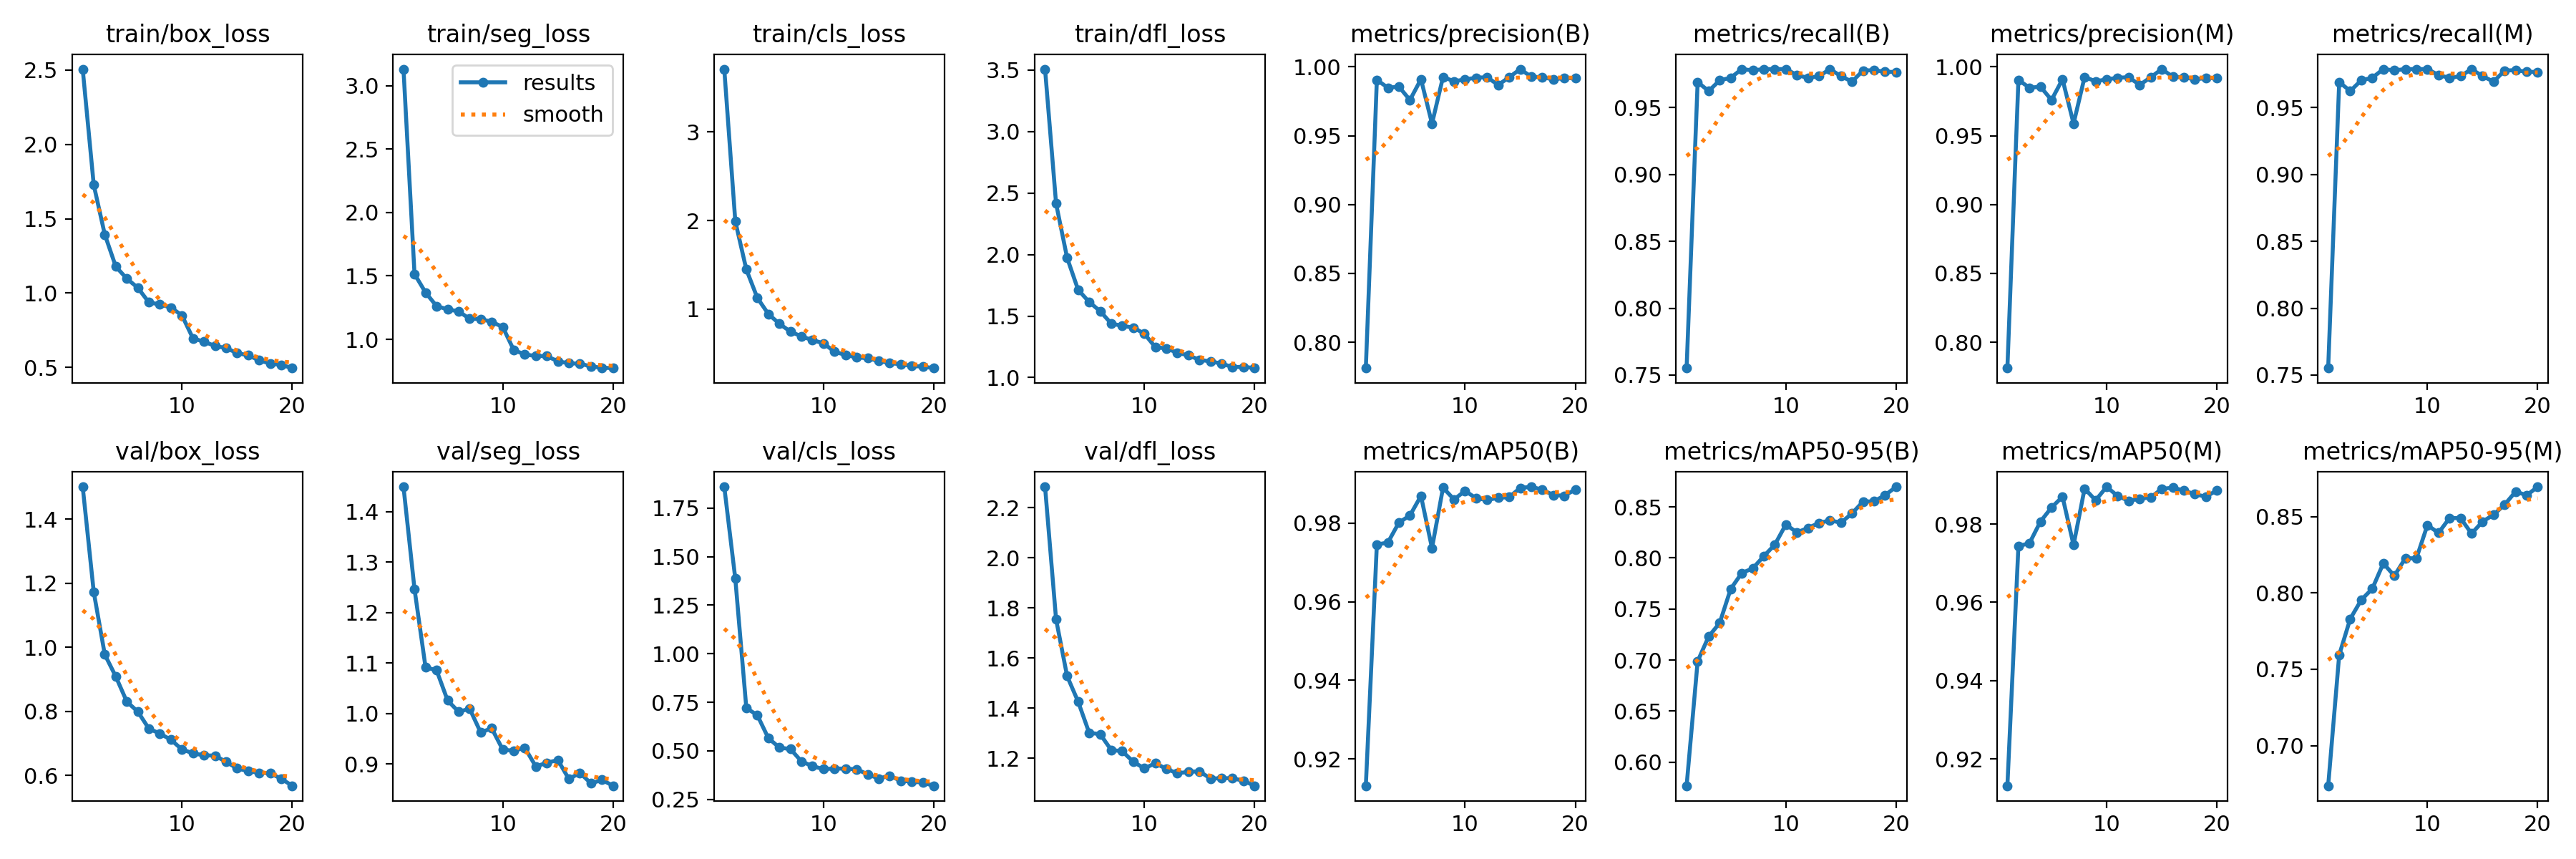

In [ ]:
# Results Graph - Training/validation graph

from IPython.display import Image, display

display(Image(filename=os.path.join(train_run_dir_ef, "results.png")))

In [ ]:
# Model Evaluation  - Validate on TEST set (not just val — this printout above is val split)

from ultralytics import YOLO

model_efficientnet = YOLO(os.path.join(train_run_dir_ef, "weights", "best.pt"))

metrics_efficientnet = model_efficientnet.val(
    data=yaml_path,
    split="test",
    imgsz=512,      # match training imgsz
    conf=0.25,
    iou=0.6,
    plots=True,
    save_json=True
)

print("=== Box Metrics (EfficientNetV2-S) — Test Set ===")
print(f"Precision:     {metrics_efficientnet.box.mp:.4f}")
print(f"Recall:        {metrics_efficientnet.box.mr:.4f}")
print(f"mAP50:         {metrics_efficientnet.box.map50:.4f}")
print(f"mAP50-95:      {metrics_efficientnet.box.map:.4f}")

print("\n=== Mask (Segmentation) Metrics (EfficientNetV2-S) — Test Set ===")
print(f"Precision:     {metrics_efficientnet.seg.mp:.4f}")
print(f"Recall:        {metrics_efficientnet.seg.mr:.4f}")
print(f"mAP50:         {metrics_efficientnet.seg.map50:.4f}")
print(f"mAP50-95:      {metrics_efficientnet.seg.map:.4f}")

Ultralytics 8.3.59 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
efficientnet_v2_s_seg summary: 944 layers, 36,712,492 parameters, 0 gradients, 223.8 GFLOPs


val: Scanning /content/wound-6/test/labels... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<00:00, 273.33it/s]

val: New cache created: /content/wound-6/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:09<00:00,  1.28it/s]


                   all        180        180      0.999          1      0.995      0.882      0.999          1      0.995      0.884
                  mild         60         60      0.998          1      0.995      0.883      0.998          1      0.995      0.854
                normal         60         60          1          1      0.995      0.829          1          1      0.995       0.85
                severe         60         60          1          1      0.995      0.932          1          1      0.995      0.947
Speed: 0.2ms preprocess, 29.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Saving runs/segment/val/predictions.json...
Results saved to runs/segment/val
=== Box Metrics (EfficientNetV2-S) — Test Set ===
Precision:     0.9994
Recall:        1.0000
mAP50:         0.9950
mAP50-95:      0.8816

=== Mask (Segmentation) Metrics (EfficientNetV2-S) — Test Set ===
Precision:     0.9994
Recall:        1.0000
mAP50:         0.9950
mAP50-95:      0.8836


 Class  Precision  Recall  mAP50  mAP50-95
  mild   0.998055     1.0  0.995  0.882846
normal   1.000000     1.0  0.995  0.829470
severe   1.000000     1.0  0.995  0.932421


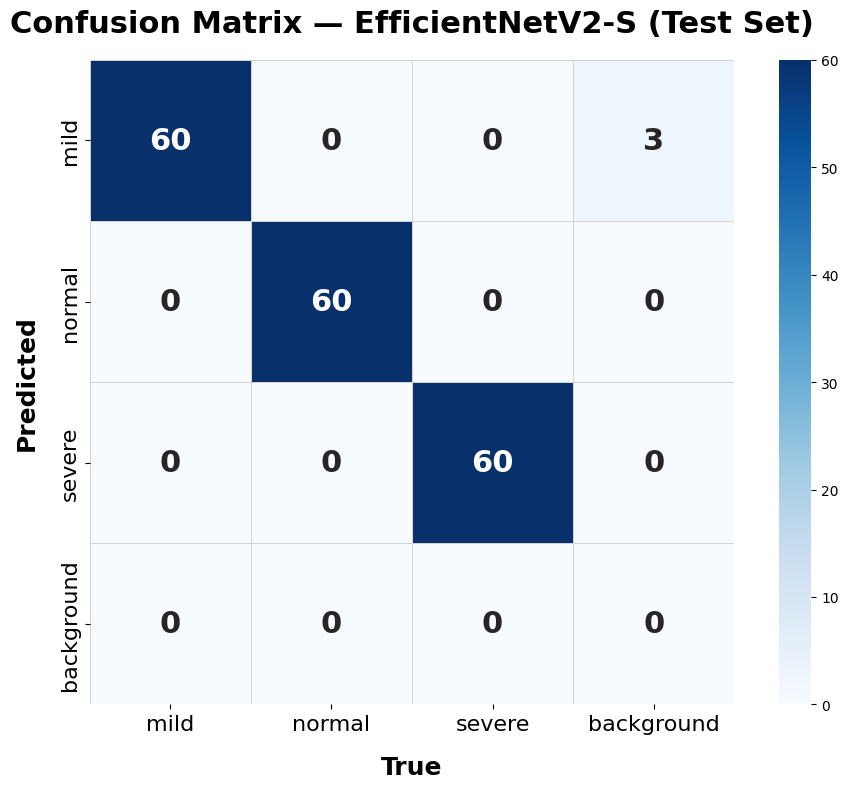

In [ ]:
# Per-class table + Confusion matrix (Test set)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class_names_list = list(data_yaml['names'].values()) if isinstance(data_yaml['names'], dict) else data_yaml['names']

rows = []
for i, cname in enumerate(class_names_list):
    rows.append({
        "Class": cname,
        "Precision": metrics_efficientnet.box.p[i],
        "Recall": metrics_efficientnet.box.r[i],
        "mAP50": metrics_efficientnet.box.ap50[i],
        "mAP50-95": metrics_efficientnet.box.ap[i],
    })
df_perf = pd.DataFrame(rows)
print(df_perf.to_string(index=False))

cm_ef = metrics_efficientnet.confusion_matrix.matrix
labels_ef = class_names_list + ["background"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_ef, annot=True, fmt='.0f', cmap='Blues',
    xticklabels=labels_ef, yticklabels=labels_ef,
    square=True, annot_kws={"size": 22, "weight": "bold"},
    linewidths=0.5, linecolor='lightgray', ax=ax
)
ax.set_xlabel("True", fontsize=18, fontweight='bold', labelpad=15)
ax.set_ylabel("Predicted", fontsize=18, fontweight='bold', labelpad=15)
ax.set_title("Confusion Matrix — EfficientNetV2-S (Test Set)", fontsize=22, fontweight='bold', pad=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig("confusion_matrix_efficientnetv2s_test.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Free GPU memory before retrying

import torch, gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(torch.cuda.memory_summary())


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 39           |        cudaMalloc retries: 39        |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  13758 MiB |  13758 MiB |  19340 MiB |   5581 MiB |
|       from large pool |  13624 MiB |  13624 MiB |  19040 MiB |   5416 MiB |
|       from small pool |    134 MiB |    134 MiB |    299 MiB |    165 MiB |
|---------------------------------------------------------------------------|
| Active memory         |  13758 MiB |  13758 MiB |  19340 MiB |   5581 MiB |
|       from large pool |  13624 MiB |  13624 MiB |  19040 MiB |